# Hydrogen-family VQE Benchmark

This notebook benchmarks `VQE` across a compact hydrogen family panel:

- `H`
- `H2`
- `H2+`
- `H2-`
- `H3`
- `H3+`
- `H4`
- `H4+`

It reports:

- resolved qubit count by system
- Hamiltonian term count
- exact same-electron-sector ground-state reference energy
- final VQE energy and absolute error
- direct compute runtime
- variational parameter count

The notebook is meant to be a decision notebook, not a tutorial. It uses the package's standard molecule pipeline, including registry-backed charge and spin multiplicity metadata, so the benchmark follows the normal cached `run_vqe(...)` path instead of local expert-mode Hamiltonian construction.

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
from IPython.display import display

from common.hamiltonian import build_hamiltonian
from common.molecules import get_molecule_config
from vqe import run_vqe

BASIS = "sto-3g"
UNIT = "angstrom"
MAPPING = "jordan_wigner"
ANSATZ = "UCCSD"
OPTIMIZER = "Adam"
STEPS = 75
STEPSIZE = 0.15
SEED = 0

HYDROGEN_SYSTEMS = ["H", "H2", "H2+", "H2-", "H3", "H3+", "H4", "H4+"]


In [2]:
def timed_call(fn, /, **kwargs):
    t0 = time.perf_counter()
    result = fn(**kwargs)
    return result, time.perf_counter() - t0


def exact_sector_ground_energy(hamiltonian, num_qubits, num_electrons):
    matrix = np.asarray(
        qml.matrix(hamiltonian, wire_order=list(range(int(num_qubits)))),
        dtype=complex,
    )
    sector_indices = [
        idx for idx in range(2 ** int(num_qubits)) if idx.bit_count() == int(num_electrons)
    ]
    if not sector_indices:
        raise ValueError(
            f"No computational-basis states found for electron sector {num_electrons}."
        )
    sector_matrix = matrix[np.ix_(sector_indices, sector_indices)]
    return float(np.min(np.linalg.eigvalsh(sector_matrix)).real)


def build_case(system):
    cfg = get_molecule_config(system)
    hamiltonian, num_qubits, _hf_state, symbols, coordinates, basis, charge, _unit_out = build_hamiltonian(
        molecule=system,
        mapping=MAPPING,
        unit=UNIT,
        return_metadata=True,
    )
    num_electrons = int(len(symbols) - int(charge))
    return {
        "system": system,
        "charge": int(charge),
        "mult": int(cfg.get("multiplicity", 1)),
        "basis": basis,
        "hamiltonian": hamiltonian,
        "num_qubits": int(num_qubits),
        "exact_ground_energy": exact_sector_ground_energy(
            hamiltonian,
            num_qubits,
            num_electrons,
        ),
        "hamiltonian_terms": int(len(hamiltonian)),
        "num_electrons": num_electrons,
    }


def benchmark_row(system, index=None, total=None):
    prefix = ""
    if index is not None and total is not None:
        prefix = f"[{index}/{total}] "
    print(
        prefix
        + f"Building {system} from the shared molecule pipeline..."
    )
    built = build_case(system)
    print(
        prefix
        + f"Running VQE for {system} on {built['num_qubits']} qubits ({built['hamiltonian_terms']} terms)..."
    )
    result, elapsed_s = timed_call(
        run_vqe,
        molecule=system,
        charge=int(built["charge"]),
        multiplicity=int(built["mult"]),
        basis=built["basis"],
        mapping=MAPPING,
        unit=UNIT,
        ansatz_name=ANSATZ,
        optimizer_name=OPTIMIZER,
        steps=STEPS,
        stepsize=STEPSIZE,
        plot=False,
        force=False,
        seed=SEED,
    )
    energy = float(result["energy"])
    row = {
        "system": built["system"],
        "charge": int(built["charge"]),
        "mult": int(built["mult"]),
        "num_electrons": int(built["num_electrons"]),
        "num_qubits": int(built["num_qubits"]),
        "hamiltonian_terms": int(built["hamiltonian_terms"]),
        "exact_ground_energy": float(built["exact_ground_energy"]),
        "energy": energy,
        "abs_error": abs(energy - float(built["exact_ground_energy"])),
        "runtime_s": float(result.get("compute_runtime_s", elapsed_s)),
        "parameter_count": len(result.get("final_params", [])),
    }
    print(
        prefix
        + f"Done: E={row['energy']:.8f} Ha, |Δ|={row['abs_error']:.2e} Ha, runtime={row['runtime_s']:.3f} s"
    )
    return row


In [3]:
rows = []
total_cases = len(HYDROGEN_SYSTEMS)
for index, system in enumerate(HYDROGEN_SYSTEMS, start=1):
    rows.append(benchmark_row(system, index=index, total=total_cases))

summary_df = pd.DataFrame(rows).sort_values(["num_qubits", "charge", "system"])

display(summary_df.round(8))


[1/8] Building H from the shared molecule pipeline...
[1/8] Running VQE for H on 2 qubits (4 terms)...
[1/8] Done: E=-0.46658185 Ha, |Δ|=0.00e+00 Ha, runtime=0.246 s
[2/8] Building H2 from the shared molecule pipeline...
[2/8] Running VQE for H2 on 4 qubits (15 terms)...
[2/8] Done: E=-1.13726795 Ha, |Δ|=2.23e-06 Ha, runtime=3.246 s
[3/8] Building H2+ from the shared molecule pipeline...
[3/8] Running VQE for H2+ on 4 qubits (15 terms)...
[3/8] Done: E=-0.53870856 Ha, |Δ|=1.02e-06 Ha, runtime=1.406 s
[4/8] Building H2- from the shared molecule pipeline...
[4/8] Running VQE for H2- on 4 qubits (15 terms)...
[4/8] Done: E=-0.44698542 Ha, |Δ|=2.96e-07 Ha, runtime=0.904 s
[5/8] Building H3 from the shared molecule pipeline...
[5/8] Running VQE for H3 on 6 qubits (62 terms)...
[5/8] Done: E=-1.29603663 Ha, |Δ|=1.86e-05 Ha, runtime=25.153 s
[6/8] Building H3+ from the shared molecule pipeline...
[6/8] Running VQE for H3+ on 6 qubits (62 terms)...
[6/8] Done: E=-1.26172871 Ha, |Δ|=8.08e-06 Ha

,system,charge,mult,num_electrons,num_qubits,hamiltonian_terms,exact_ground_energy,energy,abs_error,runtime_s,parameter_count
0,H,0,2,1,2,4,-0.466582,-0.466582,0.000000e+00,0.246430,0
3,H2-,-1,2,3,4,15,-0.446986,-0.446985,3.000000e-07,0.903565,1
1,H2,0,1,2,4,15,-1.137270,-1.137268,2.230000e-06,3.245951,3
2,H2+,1,2,1,4,15,-0.538710,-0.538709,1.020000e-06,1.405897,1
4,H3,0,2,3,6,62,-1.296055,-1.296037,1.864000e-05,25.152997,8
5,H3+,1,1,2,6,62,-1.261737,-1.261729,8.080000e-06,28.420185,8
6,H4,0,1,4,8,185,-2.166387,-2.166291,9.637000e-05,159.306871,26
7,H4+,1,2,3,8,185,-1.762826,-1.762764,6.192000e-05,119.112092,20


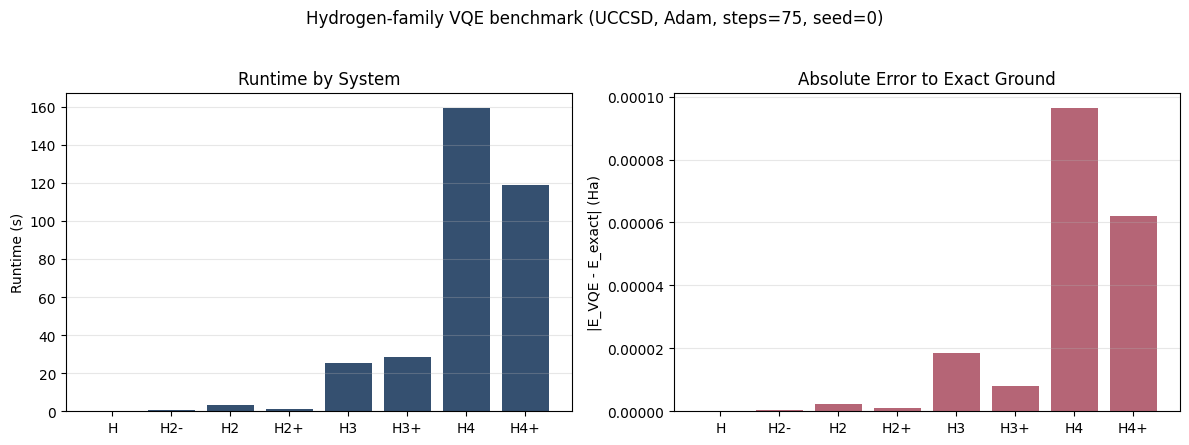

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(summary_df["system"], summary_df["runtime_s"], color="#355070")
axes[0].set_title("Runtime by System")
axes[0].set_ylabel("Runtime (s)")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(summary_df["system"], summary_df["abs_error"], color="#b56576")
axes[1].set_title("Absolute Error to Exact Ground")
axes[1].set_ylabel("|E_VQE - E_exact| (Ha)")
axes[1].grid(True, axis="y", alpha=0.3)

fig.suptitle(
    f"Hydrogen-family VQE benchmark ({ANSATZ}, {OPTIMIZER}, steps={STEPS}, seed={SEED})"
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [5]:
focus_view = summary_df[["system", "num_electrons", "num_qubits", "abs_error", "runtime_s", "parameter_count"]].copy()
focus_view = focus_view.sort_values(["abs_error", "runtime_s"])
focus_view.round(8)


,system,num_electrons,num_qubits,abs_error,runtime_s,parameter_count
0,H,1,2,0.000000e+00,0.246430,0
3,H2-,3,4,3.000000e-07,0.903565,1
2,H2+,1,4,1.020000e-06,1.405897,1
1,H2,2,4,2.230000e-06,3.245951,3
5,H3+,2,6,8.080000e-06,28.420185,8
4,H3,3,6,1.864000e-05,25.152997,8
7,H4+,3,8,6.192000e-05,119.112092,20
6,H4,4,8,9.637000e-05,159.306871,26


## Suggested Extensions

- Repeat the table with `ANSATZ = "StronglyEntanglingLayers"` if you want a second hardware-efficient baseline on the same family.
- Increase `STEPS` once you want a stronger convergence study for the larger `H4` / `H4+` systems.
- Add a companion notebook that fixes one charge sector at a time if you want to separate size effects from charge-state effects more cleanly.